In [30]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from configs.analysis_heston.full_heston_config_1 import FullConfig
from utils.analysis.delta_pnl_analysis import delta_hedge_full_analytics

# === 我们自己的 Heston / FFT / Delta ===
from src.heston_model import sim_heston_paths

from utils.pricing import fft_option_prices, fft_bump_delta

from configs.base.env_cfg import device, torch_dtype


In [31]:
# ----------------------------
# Market config
# ----------------------------
cfg = FullConfig()
market_cfg = cfg.market

S0 = market_cfg.S0
V0 = market_cfg.V0
mu = market_cfg.mu
r = market_cfg.r
T = market_cfg.T
T_steps = market_cfg.T_steps
K = 110             #
option_type = "put"           # 保持不变

dt = T / T_steps

transaction_cost_rate = market_cfg.transaction_cost_rate


In [32]:
# ----------------------------
# Simulate Heston paths (Euler, risk-neutral)
# ----------------------------
N_paths = 50_000

S_paths_t, _, V_paths_t = sim_heston_paths(
    S0=torch.tensor([S0], device=device, dtype=torch_dtype),
    V0=torch.tensor([V0], device=device, dtype=torch_dtype),
    mu=torch.tensor([mu], device=device, dtype=torch_dtype),          # 使用 r（风险中性）
    kappa=torch.tensor([market_cfg.kappa], device=device, dtype=torch_dtype),
    theta=torch.tensor([market_cfg.theta], device=device, dtype=torch_dtype),
    sigma_v=torch.tensor([market_cfg.sigma], device=device, dtype=torch_dtype),
    rho=torch.tensor([market_cfg.rho], device=device, dtype=torch_dtype),
    T=torch.tensor([T], device=device, dtype=torch_dtype),
    num_paths=N_paths,
    num_steps=T_steps,
    device=device,
)
S_paths_t = S_paths_t[0]
V_paths_t = V_paths_t[0]

In [33]:
print(
    f'S0: {S0},V0: {V0}, mu: {mu}, r: {r}, kappa: {market_cfg.kappa}, theta: {market_cfg.theta}, sigma_v: {market_cfg.sigma}'
    f'T: {T}, T_steps: {T_steps}, dt: {dt}, K: {K}, '
    f'option_type: {option_type}, transaction_cost_rate: {transaction_cost_rate}'
)

S0: 100.0,V0: 0.04, mu: 0.08, r: 0.03, kappa: 1.5, theta: 0.04, sigma_v: 0.25T: 0.25, T_steps: 60, dt: 0.004166666666666667, K: 110, option_type: put, transaction_cost_rate: 0.0


In [34]:
# ----------------------------
# 构造 tau 向量
# ----------------------------
tau_vec = T - np.arange(T_steps + 1) * dt
tau_vec = np.maximum(tau_vec, 1e-6)


In [35]:
# ----------------------------
# Vectorized FFT bump Delta paths (NO for-loop)
# ----------------------------
# S_paths, V_paths: np.ndarray, shape (N_paths, T_steps+1)

batch_size = 50

with torch.no_grad():
    # 转成 torch（只取 0 ~ T_steps-1）
    S_mat = S_paths_t[:, :-1]
    V_mat = V_paths_t[:, :-1]

    N, Tn = S_mat.shape

    # K / r 扩展成 (N, T)
    K_mat = torch.full((N, Tn), K, device=device, dtype=torch_dtype)
    r_mat = torch.full((N, Tn), r, device=device, dtype=torch_dtype)

    # tau 扩展成 (N, T)
    T_mat = (
        torch.tensor(tau_vec[:-1], device=device, dtype=torch_dtype)
        .unsqueeze(0)
        .expand(N, Tn)
    )

    # option type 矩阵
    option_types_mat = torch.full(
        (N, Tn),
        1.0 if option_type == "call" else 0.0,
        device=device,
    )

    delta_paths_core = torch.zeros(N, Tn, device=device, dtype=torch_dtype)


    for i in range(0, N, batch_size):
        end = min(i + batch_size, N)

        delta_paths_core[i:end] = fft_bump_delta(
            S=S_mat[i:end],
            V=V_mat[i:end],
            K=K_mat[i:end],
            T=T_mat[i:end],
            r=r_mat[i:end],
            kappa=torch.tensor(market_cfg.kappa, device=device, dtype=torch_dtype),
            theta=torch.tensor(market_cfg.theta, device=device, dtype=torch_dtype),
            sigma_v=torch.tensor(market_cfg.sigma, device=device, dtype=torch_dtype),
            rho=torch.tensor(market_cfg.rho, device=device, dtype=torch_dtype),
            option_types=option_types_mat[i:end],
        )

        torch.mps.empty_cache()  # 防爆显存


In [36]:
S_paths = S_paths_t.squeeze(0).cpu().numpy()     # (N, T+1)
V_paths = V_paths_t.squeeze(0).cpu().numpy()

# ----------------------------
# 到期 Delta（欧式期权）
# ----------------------------

# 组装完整 delta_paths: (N, T+1)
delta_paths = np.zeros_like(S_paths)
delta_paths[:, :-1] = delta_paths_core.cpu().numpy()

delta_T = np.where(
    S_paths[:, -1] > K,
    1.0 if option_type == "call" else 0.0,
    0.0 if option_type == "call" else -1.0,
)

delta_paths[:, -1] = delta_T

In [37]:
# ----------------------------
# 初始期权价格（FFT，替代 QuantLib NPV）
# ----------------------------
initial_option_price = fft_option_prices(
    S=torch.tensor([S0], device=device, dtype=torch_dtype),
    V=torch.tensor([V0], device=device, dtype=torch_dtype),
    K=torch.tensor([K], device=device, dtype=torch_dtype),
    T=torch.tensor([T], device=device, dtype=torch_dtype),
    r=torch.tensor([r], device=device, dtype=torch_dtype),
    kappa=torch.tensor(market_cfg.kappa, device=device, dtype=torch_dtype),
    theta=torch.tensor(market_cfg.theta, device=device, dtype=torch_dtype),
    sigma=torch.tensor(market_cfg.sigma, device=device, dtype=torch_dtype),
    rho=torch.tensor(market_cfg.rho, device=device, dtype=torch_dtype),
    option_types=torch.tensor(
        [1.0 if option_type == "call" else 0.0],
        device=device,
    ),
).item()


In [38]:
# ----------------------------
# Delta hedging PnL analysis
# ----------------------------
results_heston = delta_hedge_full_analytics(
    S_paths=S_paths,
    delta_paths=delta_paths,
    initial_option_price=initial_option_price,
    K=K,
    option_type=option_type,
    r=r,
    transaction_cost_rate=transaction_cost_rate,  # 10bp
    dt=dt,
)


In [39]:
terminal_pnl = results_heston["terminal_pnl"]
print(f"Mean P&L : {np.mean(terminal_pnl):.6f}")
print(f"Std P&L : {np.std(terminal_pnl):.6f}")
print(f"5% Quantile : {np.quantile(terminal_pnl, 0.05):.6f}")
print(f"95% Quantile : {np.quantile(terminal_pnl, 0.95):.6f}")
print(f"Mean TC : {np.mean(results_heston['total_tc']):.6f}")


Mean P&L : -0.001082
Std P&L : 0.643357
5% Quantile : -0.990988
95% Quantile : 1.144364
Mean TC : 0.000000


# actor - critic0 models

In [40]:
# =============================================================================
# 4. Actor–Critic comparison（完全保留原逻辑）
# =============================================================================
from utils.model_saver import load_full_experiment
from src.data_processing import make_state_t

def load_actor_and_critic0(load_dir, actor_lambda, device, torch_dtype):
    (
        critic0,
        market_cfg,
        critic0_cfg,
        runtime_cfg,
        actor,
        actor_cfg,
        critic,
        critic_cfg
    ) = load_full_experiment(
        load_dir=load_dir,
        device=device,
        torch_dtype=torch_dtype,
        actor_lambda=actor_lambda,
        critic_lambda=actor_lambda,
    )
    actor.eval()
    critic0.eval()
    return actor, critic0, market_cfg, runtime_cfg, critic, critic_cfg

@torch.no_grad()
def actor_critic0_slice(
        actor, critic0, critic,
        S_path: torch.Tensor,
        K,
        t_path: torch.Tensor,
        device, torch_dtype
):
    S_over_K = S_path / K
    state = make_state_t(
        S_over_K,
        t_path,
    )
    actions = actor.mean(state)
    astar = critic.a_star(state)
    Q = critic0(state, actions)
    return actions * (K / S_path), astar * (K / S_path), -Q * K

load_dir = (
    "models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0"
)

actor, critic0, rl_mkt_cfg, rl_rt_cfg, critic, critic_cfg = load_actor_and_critic0(
    load_dir=load_dir,
    actor_lambda=100_000.0,
    device=device,
    torch_dtype=torch_dtype,
)

with torch.no_grad():
    actions, a_star, C0_critic = actor_critic0_slice(
        actor=actor,
        critic0=critic0,
        critic=critic,
        S_path=S_paths_t[:,:-1],
        K=K,
        t_path=T_mat,
        device=device,
        torch_dtype=torch_dtype,
    )
    C0_critic = C0_critic.cpu().numpy()

=== Loading full experiment ===
当前工作目录：/Users/hy/PycharmProjects/qlbs_rl
当前已是qlbs_rl根目录，无需切换
[MarketArtifactLoader] Loaded market artifact: 
path            : models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

Market artifact loaded
[ActorLoader] Loaded actor λ=100000.0
  path: models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32
Actor loaded (λ=100000.0)
[CriticLoader] Loaded critic λ=100000.0
  path: models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0/actor_lambda_100000.0000/critic_100000.0000.pt
  device: mps
Critic loaded (λ=100000.0)
=== Full experiment loaded ===


In [41]:
# 组装完整 actor_action_paths: (N, T+1)
actor_action_paths = np.zeros_like(S_paths)
astar_action_paths = np.zeros_like(S_paths)
actor_action_paths[:, :-1] = actions.cpu().numpy()
astar_action_paths[:, :-1] = a_star.cpu().numpy()

delta_T = np.where(
    S_paths[:, -1] > K,
    1.0 if option_type == "call" else 0.0,
    0.0,
)

actor_action_paths[:, -1] = delta_T
astar_action_paths[:, -1] = delta_T
torch.mps.empty_cache()

In [42]:
initial_option_price

10.072975158691406

In [43]:
# ----------------------------
# Delta hedging PnL analysis
# ----------------------------
results_acc_actions = delta_hedge_full_analytics(
    S_paths=S_paths,
    delta_paths=actor_action_paths,

    initial_option_price=initial_option_price,
    K=K,
    option_type=option_type,
    r=r,
    transaction_cost_rate=transaction_cost_rate,  # 10bp
    dt=dt,
)
results_astar = delta_hedge_full_analytics(
    S_paths=S_paths,
    delta_paths=astar_action_paths,

    initial_option_price=initial_option_price,
    K=K,
    option_type=option_type,
    r=r,
    transaction_cost_rate=transaction_cost_rate,  # 10bp
    dt=dt,
)


compare heston and qlbs

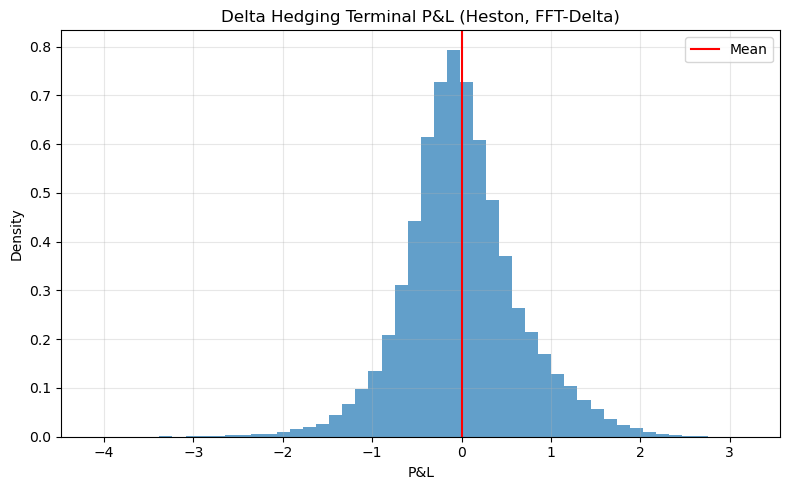

In [44]:
# heston
terminal_pnl = results_heston["terminal_pnl"]
plt.figure(figsize=(8, 5))
plt.hist(terminal_pnl, bins=50, density=True, alpha=0.7)
plt.axvline(np.mean(terminal_pnl), color="red", label="Mean")
plt.title("Delta Hedging Terminal P&L (Heston, FFT-Delta)")
plt.xlabel("P&L")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

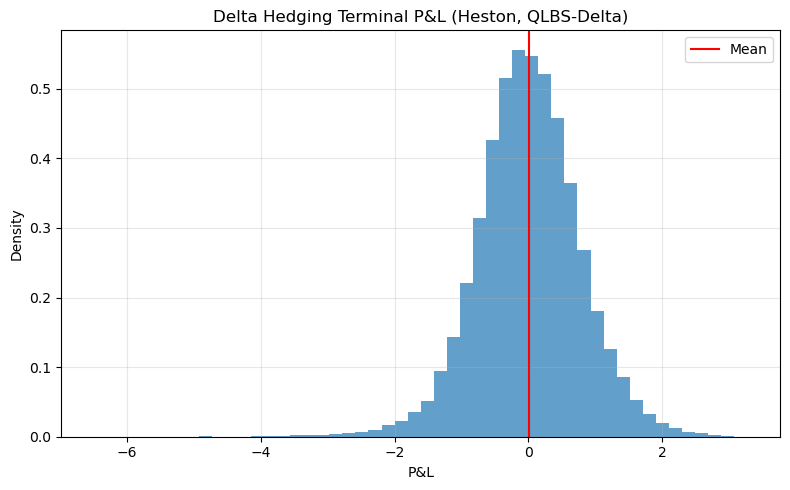

In [45]:
terminal_pnl_actions = results_acc_actions["terminal_pnl"]
plt.figure(figsize=(8, 5))
plt.hist(terminal_pnl_actions, bins=50, density=True, alpha=0.7)
plt.axvline(np.mean(terminal_pnl_actions), color="red", label="Mean")
plt.title("Delta Hedging Terminal P&L (Heston, QLBS-Delta)")
plt.xlabel("P&L")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


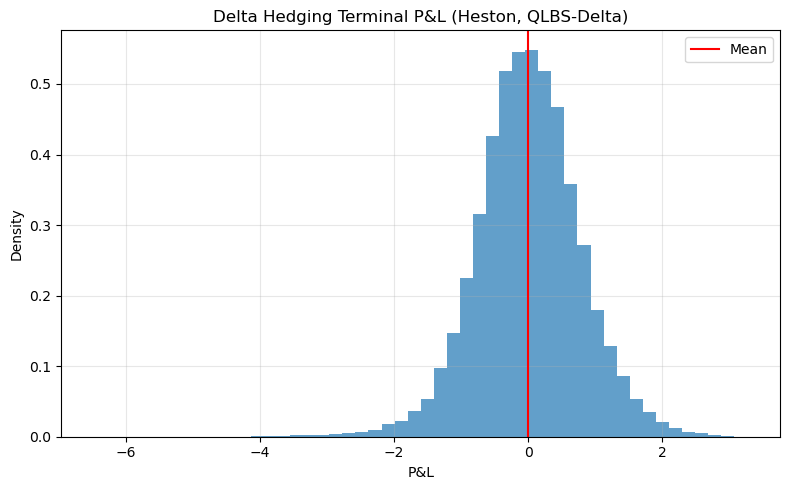

In [46]:
terminal_pnl_astar = results_astar["terminal_pnl"]
plt.figure(figsize=(8, 5))
plt.hist(terminal_pnl_astar, bins=50, density=True, alpha=0.7)
plt.axvline(np.mean(terminal_pnl_astar), color="red", label="Mean")
plt.title("Delta Hedging Terminal P&L (Heston, QLBS-Delta)")
plt.xlabel("P&L")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:

N_paths = S_paths.shape[0]
n_plot = 10

rng = np.random.default_rng(seed=42)
plot_indices = rng.choice(N_paths, size=n_plot, replace=False)

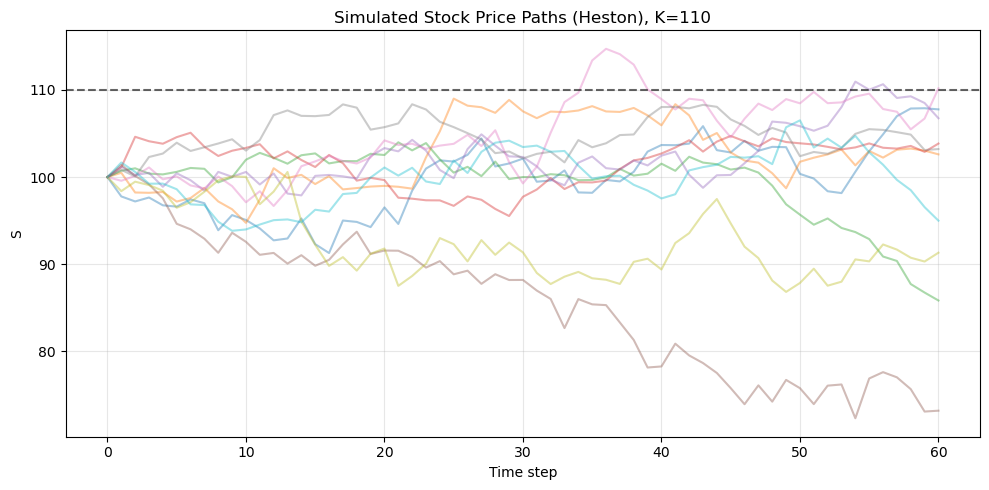

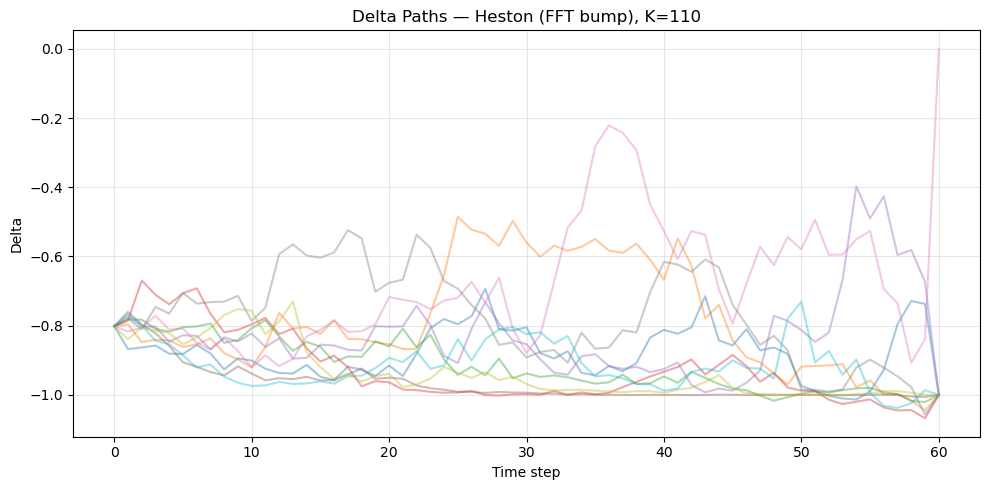

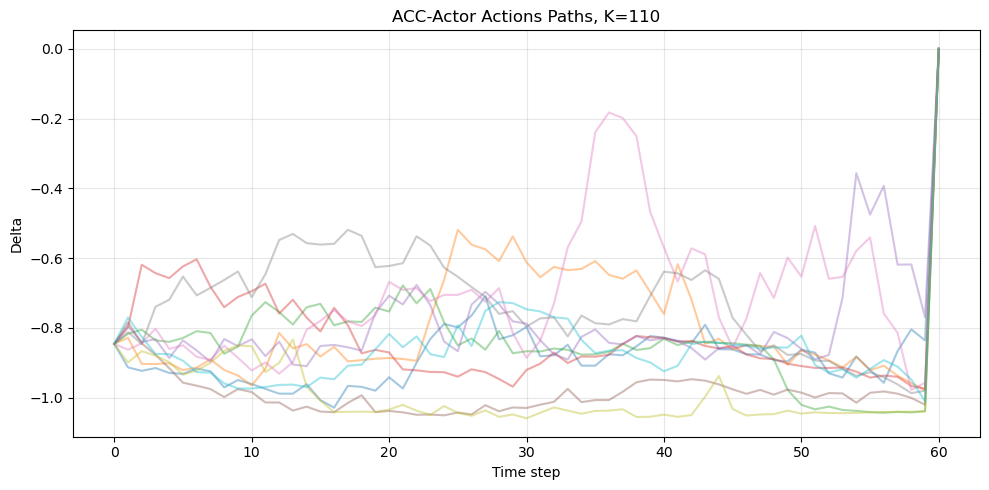

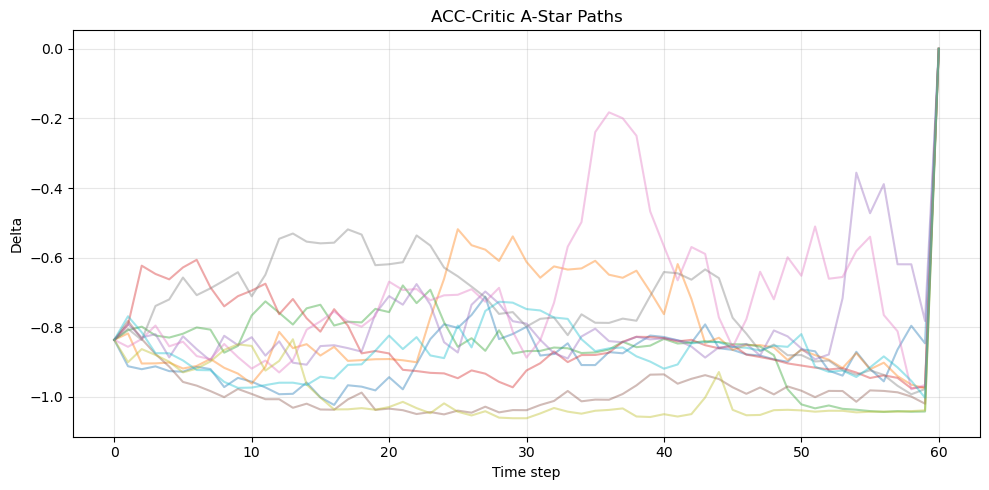

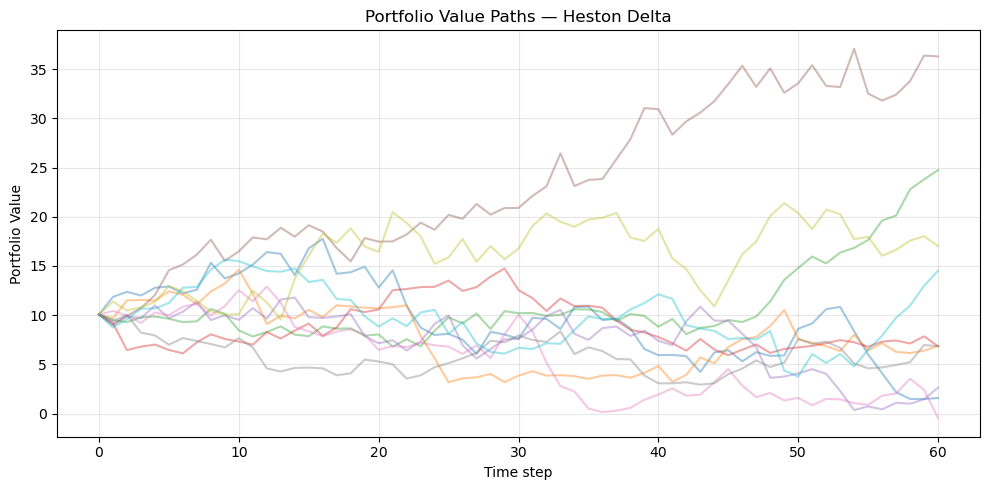

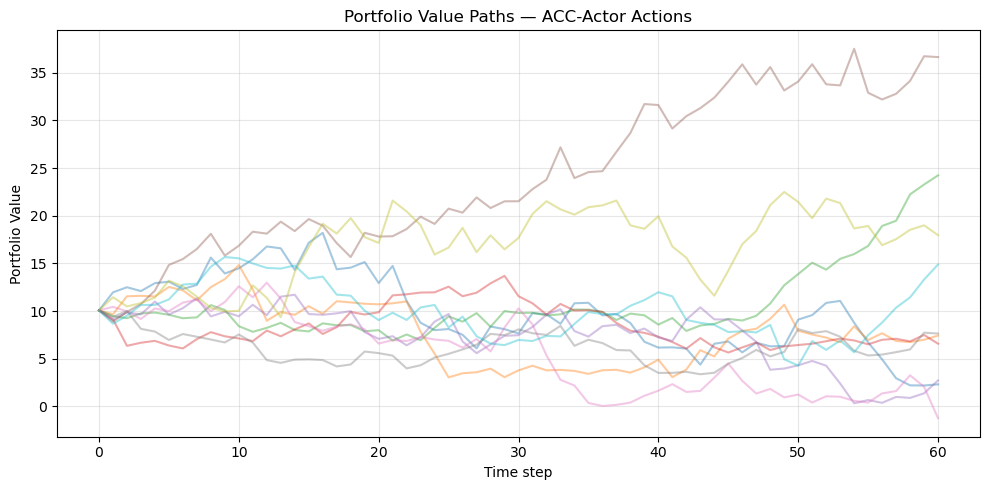

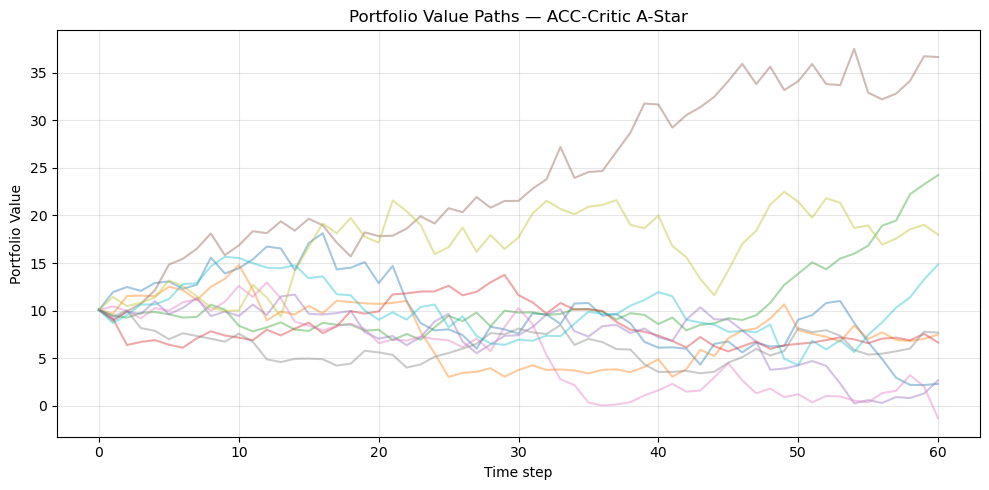

In [59]:

t = np.arange(S_paths.shape[1])

# ==============================
# Figure 1: S_paths (50 条)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, S_paths[i], alpha=0.4)
plt.axhline(K, color="black", ls="--", alpha=0.6)
plt.title(f"Simulated Stock Price Paths (Heston), K={K}")
plt.xlabel("Time step")
plt.ylabel("S")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Figure 2: Delta paths (Heston)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, delta_paths[i], alpha=0.4)
plt.title(f"Delta Paths — Heston (FFT bump), K={K}")
plt.xlabel("Time step")
plt.ylabel("Delta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Figure 3: Actions paths (ACC-Actor)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, actor_action_paths[i], alpha=0.4)
plt.title(f"ACC-Actor Actions Paths, K={K}")
plt.xlabel("Time step")
plt.ylabel("Delta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Figure 3: Astar paths (ACC-Actor)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, astar_action_paths[i], alpha=0.4)
plt.title("ACC-Critic A-Star Paths")
plt.xlabel("Time step")
plt.ylabel("Delta")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Figure 4: Portfolio paths (Heston)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, results_heston["portfolio_paths"][i], alpha=0.4)
plt.title("Portfolio Value Paths — Heston Delta")
plt.xlabel("Time step")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Figure 5: Portfolio paths (actions)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, results_acc_actions["portfolio_paths"][i], alpha=0.4)
plt.title("Portfolio Value Paths — ACC-Actor Actions")
plt.xlabel("Time step")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Figure 5: Portfolio paths (astar)
# ==============================
plt.figure(figsize=(10, 5))
for i in plot_indices:
    plt.plot(t, results_astar["portfolio_paths"][i], alpha=0.4)
plt.title("Portfolio Value Paths — ACC-Critic A-Star")
plt.xlabel("Time step")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
import matplotlib.pyplot as plt

def plot_pathwise_comparison(
    idx,
    S_paths,
    delta_heston,
    delta_qlbs,
    portfolio_heston,
    portfolio_qlbs,
    K,
):
    """
    对单一路径 idx 画 3 个子图：
    1. Asset price
    2. Delta paths
    3. Portfolio value
    """

    T_plus_1 = S_paths.shape[1]
    t_grid = np.arange(T_plus_1)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # ---------- 1. S path ----------
    axes[0].plot(t_grid, S_paths[idx], color="black", lw=2)
    axes[0].axhline(K, color="gray", ls="--", alpha=0.5, label="Strike")
    axes[0].set_ylabel("S")
    axes[0].set_title(f"Path {idx} — Asset Price")
    axes[0].grid(alpha=0.3)

    # ---------- 2. Delta paths ----------
    axes[1].plot(
        t_grid, delta_heston[idx],
        label="Heston Δ (FFT)",
        lw=2,
        color="tab:blue"
    )
    axes[1].plot(
        t_grid, delta_qlbs[idx],
        label="QLBS Δ",
        lw=2,
        ls="--",
        color="tab:orange"
    )
    axes[1].set_ylabel("Delta")
    axes[1].set_title("Delta Hedge")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # ---------- 3. Portfolio value ----------
    axes[2].plot(
        t_grid, portfolio_heston[idx],
        label="Heston Δ Portfolio",
        lw=2,
        color="tab:blue"
    )
    axes[2].plot(
        t_grid, portfolio_qlbs[idx],
        label="QLBS Portfolio",
        lw=2,
        ls="--",
        color="tab:orange"
    )
    axes[2].set_ylabel("Portfolio Value")
    axes[2].set_xlabel("Time step")
    axes[2].set_title("Portfolio Value Evolution")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [50]:
# t_grid.shape

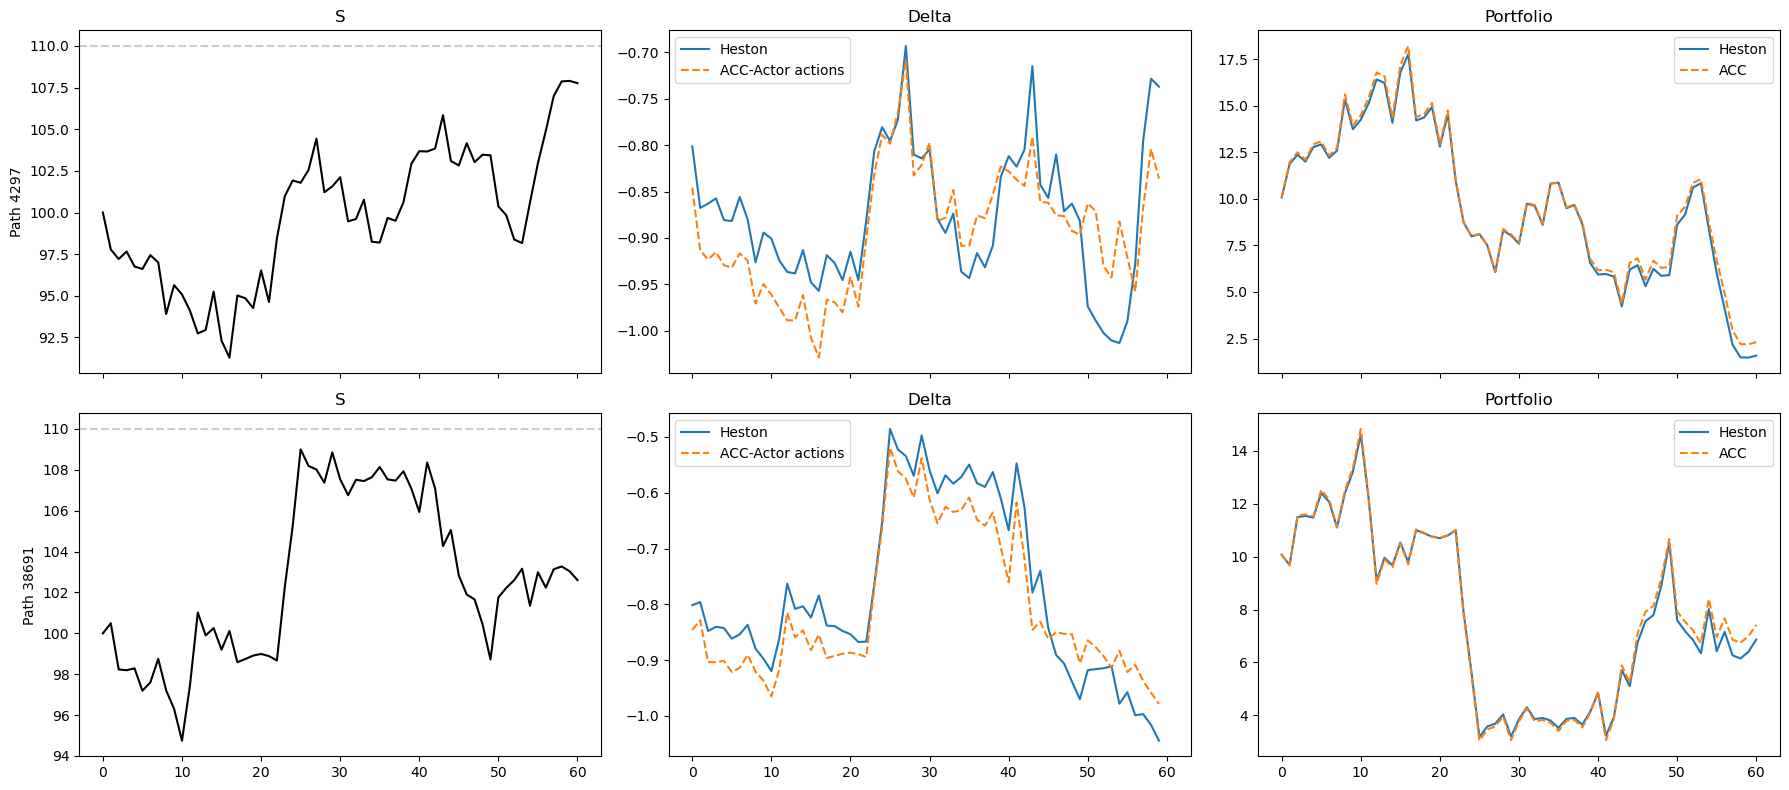

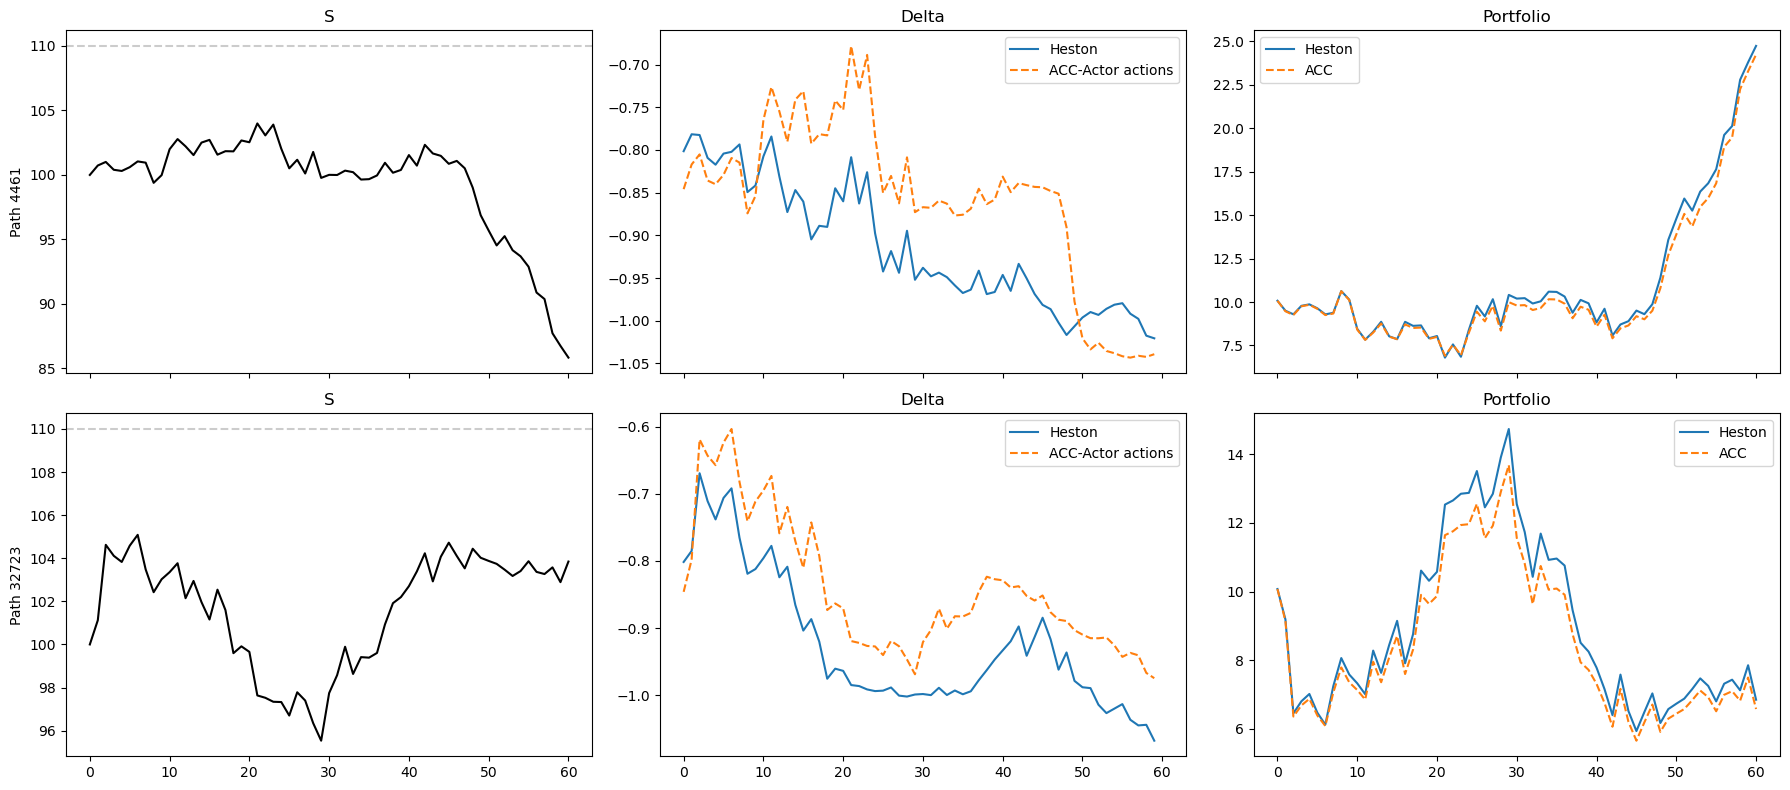

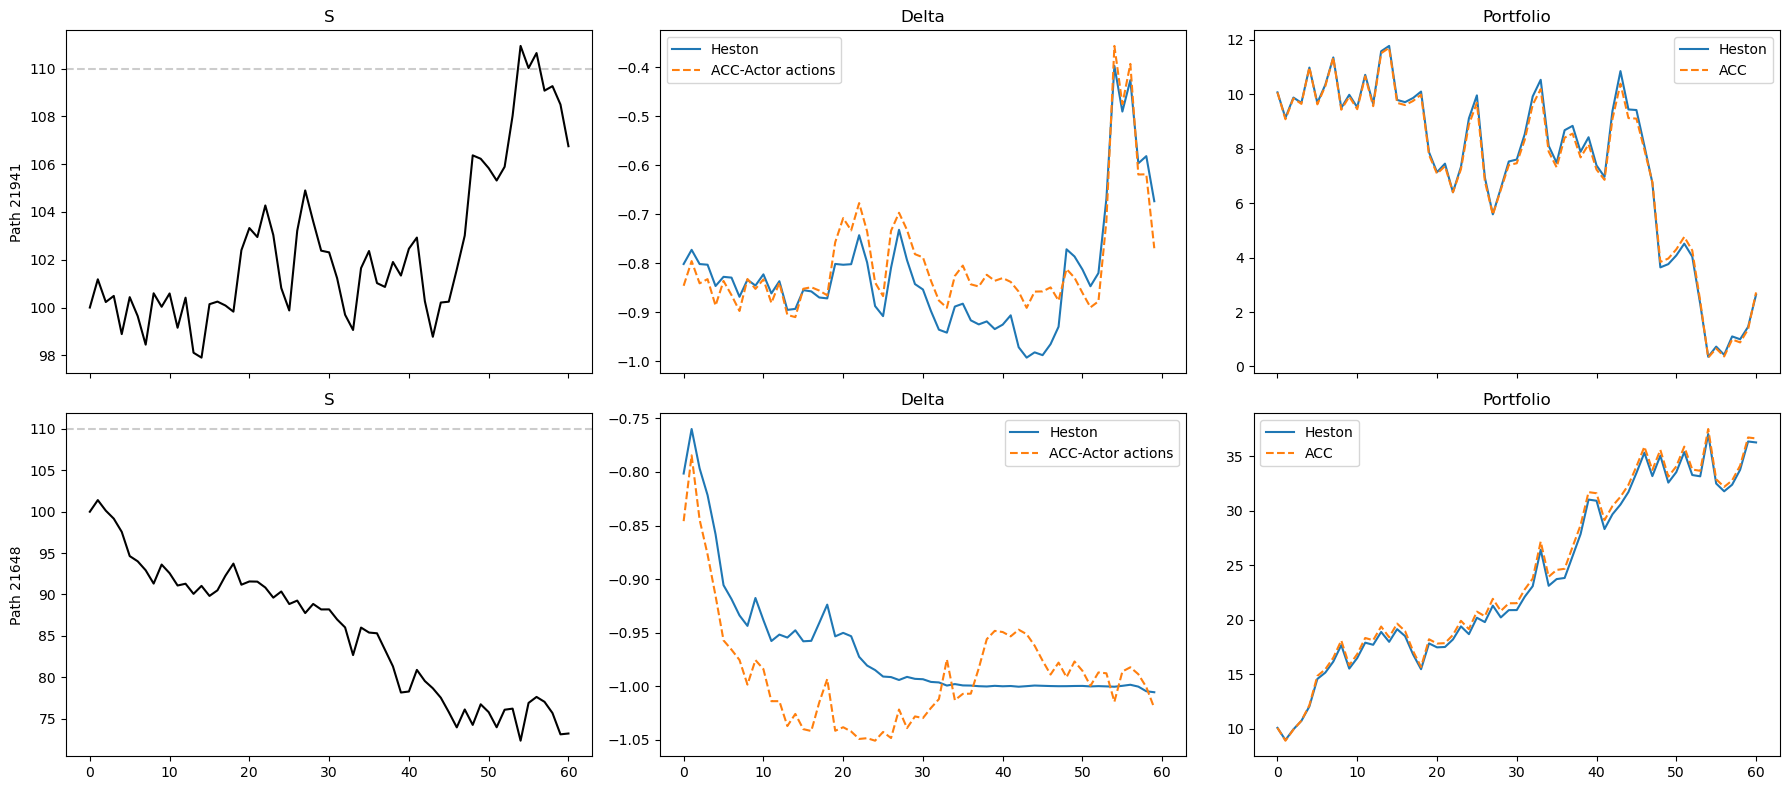

In [51]:
batch = 2
for i in range(0, 5, batch):
    fig, axes = plt.subplots(batch, 3, figsize=(18, 4 * batch), sharex=True)

    for j, idx in enumerate(plot_indices[i:i+batch]):
        t_grid = np.arange(S_paths.shape[1])

        # S
        axes[j, 0].plot(t_grid, S_paths[idx], color="black")
        axes[j, 0].axhline(K, color="gray", ls="--", alpha=0.4)
        axes[j, 0].set_ylabel(f"Path {idx}")
        axes[j, 0].set_title("S")

        # Delta
        axes[j, 1].plot(t_grid[:-1], delta_paths[idx, :-1], label="Heston")
        axes[j, 1].plot(t_grid[:-1], actor_action_paths[idx, :-1], "--", label="ACC-Actor actions")
        axes[j, 1].set_title("Delta")
        axes[j, 1].legend()

        # Portfolio
        axes[j, 2].plot(
            t_grid, results_heston["portfolio_paths"][idx],
            label="Heston"
        )
        axes[j, 2].plot(
            t_grid, results_acc_actions["portfolio_paths"][idx],
            "--",
            label="ACC"
        )
        axes[j, 2].set_title("Portfolio")
        axes[j, 2].legend()

    plt.tight_layout()
    plt.show()


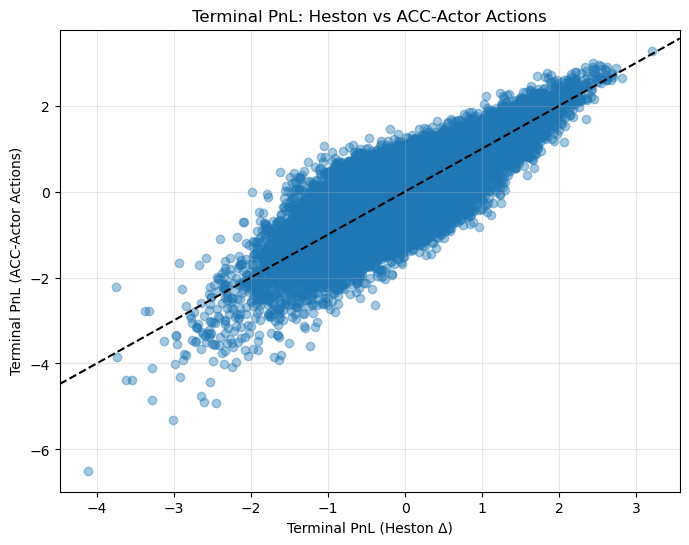

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(
    results_heston["terminal_pnl"],
    results_acc_actions["terminal_pnl"],
    alpha=0.4
)
plt.axline((0, 0), (1, 1), color="black", ls="--")
plt.xlabel("Terminal PnL (Heston Δ)")
plt.ylabel("Terminal PnL (ACC-Actor Actions)")
plt.title("Terminal PnL: Heston vs ACC-Actor Actions")
plt.grid(alpha=0.3)
plt.show()

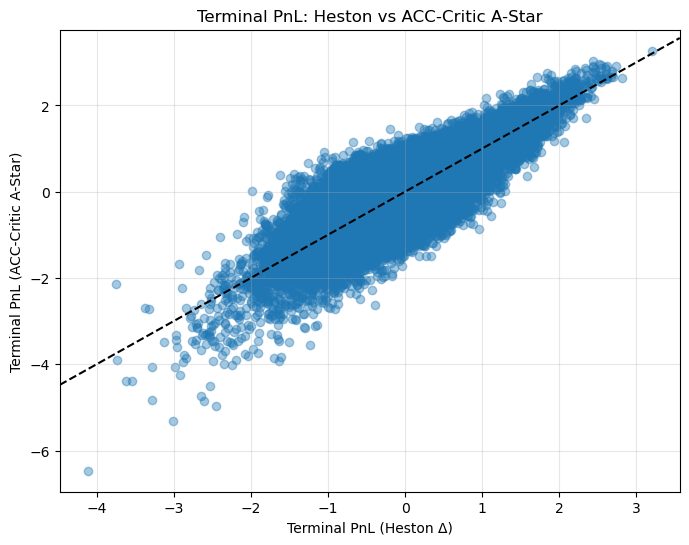

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(
    results_heston["terminal_pnl"],
    results_astar["terminal_pnl"],
    alpha=0.4
)
plt.axline((0, 0), (1, 1), color="black", ls="--")
plt.xlabel("Terminal PnL (Heston Δ)")
plt.ylabel("Terminal PnL (ACC-Critic A-Star)")
plt.title("Terminal PnL: Heston vs ACC-Critic A-Star")
plt.grid(alpha=0.3)
plt.show()

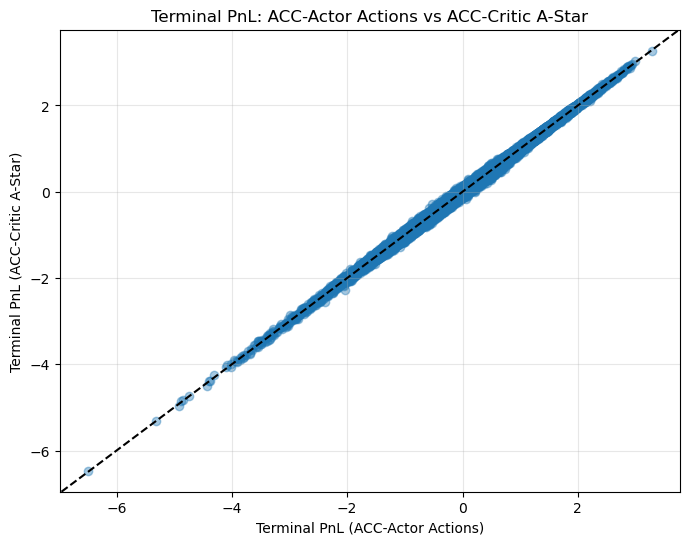

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(
    results_acc_actions["terminal_pnl"],
    results_astar["terminal_pnl"],
    alpha=0.4
)
plt.axline((0, 0), (1, 1), color="black", ls="--")
plt.xlabel("Terminal PnL (ACC-Actor Actions)")
plt.ylabel("Terminal PnL (ACC-Critic A-Star)")
plt.title("Terminal PnL: ACC-Actor Actions vs ACC-Critic A-Star")
plt.grid(alpha=0.3)
plt.show()

In [55]:
C0_critic[0,0], initial_option_price, np.mean(terminal_pnl), np.mean(terminal_pnl_actions)


(np.float32(10.207684),
 10.072975158691406,
 np.float64(-0.001081718693915205),
 np.float64(0.0036780929767745896))

In [56]:
print('Heston analytics')
print(f"Mean P&L : {np.mean(terminal_pnl):.6f}")
print(f"Median P&L : {np.median(terminal_pnl):.6f}")
print(f"Std P&L : {np.std(terminal_pnl):.6f}")
print(f"5% Quantile : {np.quantile(terminal_pnl, 0.05):.6f}")
print(f"95% Quantile : {np.quantile(terminal_pnl, 0.95):.6f}")
# print(f"Mean TC : {np.mean(results_heston['total_tc']):.6f}")
print()
print('ACC-Actor Actions')
print(f"Mean P&L : {np.mean(terminal_pnl_actions):.6f}")
print(f"Median P&L : {np.median(terminal_pnl_actions):.6f}")
print(f"Std P&L : {np.std(terminal_pnl_actions):.6f}")
print(f"5% Quantile : {np.quantile(terminal_pnl_actions, 0.05):.6f}")
print(f"95% Quantile : {np.quantile(terminal_pnl_actions, 0.95):.6f}")
# print(f"Mean TC : {np.mean(results_acc_actions['total_tc']):.6f}")
print()
print('ACC-Critic A-Star')
print(f"Mean P&L : {np.mean(terminal_pnl_astar):.6f}")
print(f"Median P&L : {np.median(terminal_pnl_astar):.6f}")
print(f"Std P&L : {np.std(terminal_pnl_astar):.6f}")
print(f"5% Quantile : {np.quantile(terminal_pnl_astar, 0.05):.6f}")
print(f"95% Quantile : {np.quantile(terminal_pnl_astar, 0.95):.6f}")
# print(f"Mean TC : {np.mean(results_acc_actions['total_tc']):.6f}")

Heston analytics
Mean P&L : -0.001082
Median P&L : -0.040853
Std P&L : 0.643357
5% Quantile : -0.990988
95% Quantile : 1.144364

ACC-Actor Actions
Mean P&L : 0.003678
Median P&L : 0.000785
Std P&L : 0.768518
5% Quantile : -1.215298
95% Quantile : 1.255140

ACC-Critic A-Star
Mean P&L : 0.004185
Median P&L : 0.002077
Std P&L : 0.770539
5% Quantile : -1.221419
95% Quantile : 1.262497


In [57]:
initial_option_price - np.mean(terminal_pnl)

np.float64(10.074056877385322)

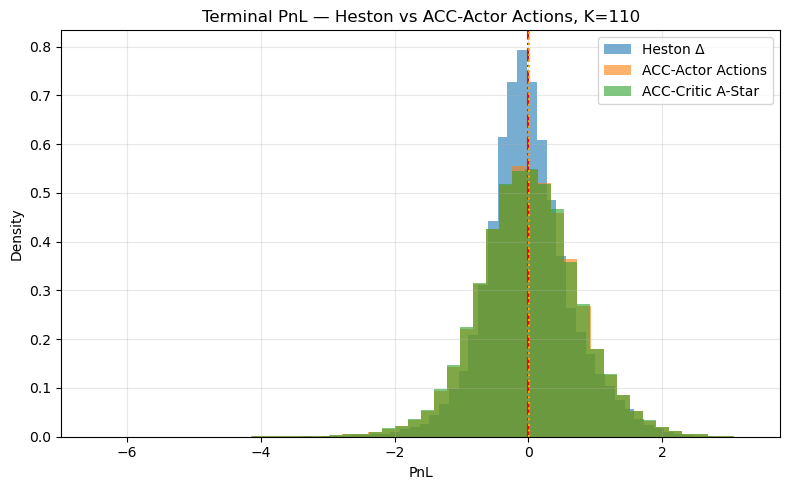

In [60]:
# ============================================================
# Plots
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(terminal_pnl, bins=50, density=True, alpha=0.6, label="Heston Δ")
plt.hist(terminal_pnl_actions, bins=50, density=True, alpha=0.6, label="ACC-Actor Actions")
plt.hist(terminal_pnl_astar, bins=50, density=True, alpha=0.6, label="ACC-Critic A-Star")
plt.axvline(np.mean(terminal_pnl), color="red", ls="-.")
plt.axvline(np.mean(terminal_pnl_actions), color="orange", ls=":")
plt.legend()
plt.title(f"Terminal PnL — Heston vs ACC-Actor Actions, K={K}")
plt.xlabel("PnL")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()